## Polychronous Chain

On va créer ici un graphe dynamique qui va relier N neurons entre eux de telle sorte à ce que chaque neurone soit connecté à M autres neurones

In [1]:
%pip install brian2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 21.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 66.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 10.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [brian2]2m3/4 [brian2]
Note: you may need to restart the kernel to use updated packages.


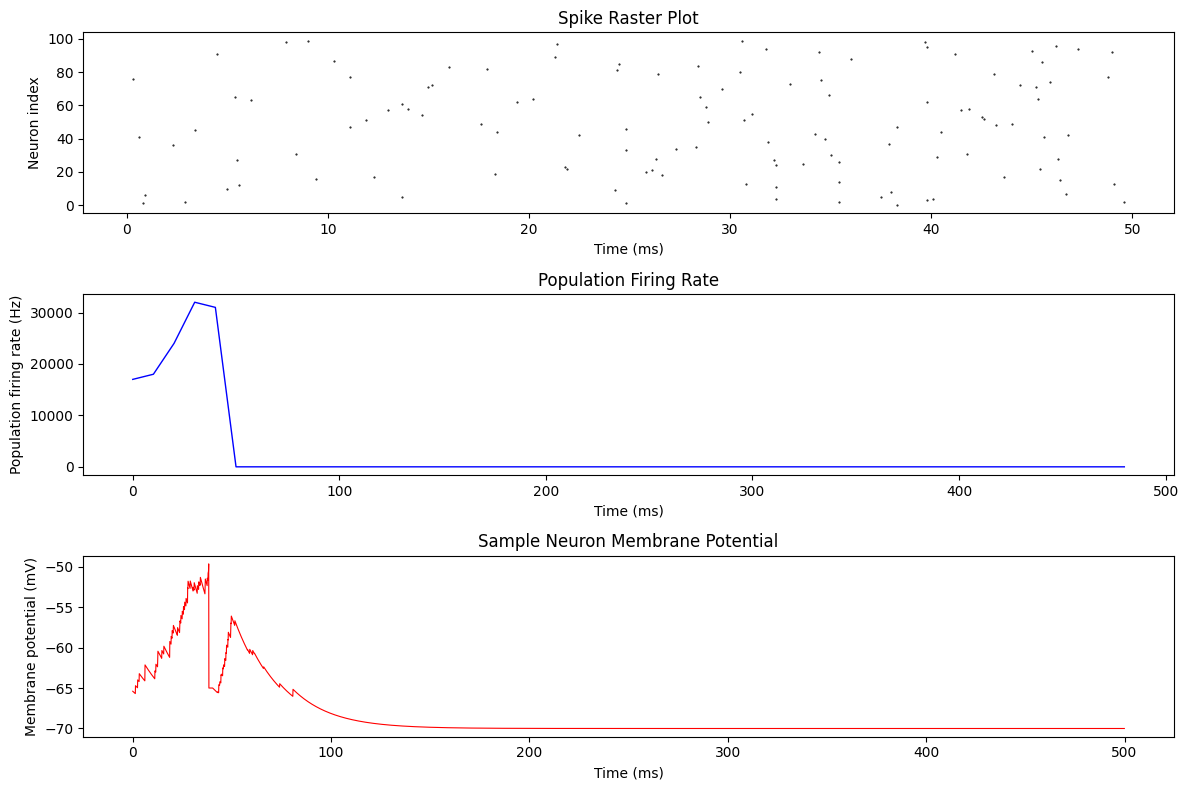

Total spikes recorded: 122
Mean firing rate: 2.44 Hz/neuron
Connection density: 19.9%


In [2]:
import numpy as np
from brian2 import *
import matplotlib.pyplot as plt

# Set up the simulation
defaultclock.dt = 0.1*ms
start_scope()

# Network parameters
N = 100  # Number of neurons
duration = 500*ms  # Simulation duration

# LIF neuron parameters
tau_m = 20*ms      # Membrane time constant
V_rest = -70*mV    # Resting potential
V_th = -50*mV      # Spike threshold
V_reset = -65*mV   # Reset potential
R_m = 100*Mohm     # Membrane resistance
tau_refractory = 2*ms  # Refractory period

# Synaptic parameters
delay_min = 2*ms   # Minimum synaptic delay
delay_max = 40*ms  # Maximum synaptic delay
synaptic_weight = 0.5*mV  # Base synaptic weight
sparsity = 0.2     # Connection probability (20% connectivity)

# Define LIF neuron equations
eqs = '''
dv/dt = (-(v - V_rest) + R_m*I_syn)/tau_m : volt (unless refractory)
I_syn : amp  # Synaptic current input
'''

# Create neuron group
neurons = NeuronGroup(N, eqs,
                      threshold='v > V_th',
                      reset='v = V_reset',
                      refractory=tau_refractory,
                      method='euler')

# Initialize membrane potentials randomly between resting and threshold
neurons.v = V_rest + (V_th - V_rest) * np.random.rand(N)

# Create synapses with random delays
synapses = Synapses(neurons, neurons,
                   'w : volt',  # Synaptic weight variable
                   on_pre='v_post += w')  # When pre-synaptic neuron fires

# Connect neurons sparsely (20% probability)
synapses.connect(p=sparsity)

# Assign random synaptic weights and delays
synapses.w = synaptic_weight * np.random.exponential(1, size=len(synapses))
synapses.delay = delay_min + (delay_max - delay_min) * np.random.rand(len(synapses))

# Add external Poisson input to initiate activity
poisson_rate = 50*Hz  # Rate of external inputs
external_input = PoissonInput(neurons, 'v', N=20, rate=poisson_rate, weight=1*mV)

# Monitor spikes for visualization
spike_monitor = SpikeMonitor(neurons)
state_monitor = StateMonitor(neurons, 'v', record=[0])  # Record first neuron

# Run simulation in two phases: stimulation then free-running
stim_duration = 50*ms
run(stim_duration)  # Initial stimulation

# Remove external input for sustained activity observation
del external_input
run(duration - stim_duration)  # Continue without external input

# Plot results
plt.figure(figsize=(12, 8))

# Raster plot of spikes
plt.subplot(3, 1, 1)
plot(spike_monitor.t/ms, spike_monitor.i, '.k', markersize=1)
plt.xlabel('Time (ms)')
plt.ylabel('Neuron index')
plt.title('Spike Raster Plot')

# Firing rate over time (binned)
plt.subplot(3, 1, 2)
bin_size = 10*ms
bins = np.arange(0, duration/ms, bin_size/ms)
spike_times_ms = spike_monitor.t/ms
histogram, _ = np.histogram(spike_times_ms, bins=bins)
plt.plot(bins[:-1], histogram/bin_size/N*1000, 'b-', linewidth=1)
plt.xlabel('Time (ms)')
plt.ylabel('Population firing rate (Hz)')
plt.title('Population Firing Rate')

# Sample membrane potential trace
plt.subplot(3, 1, 3)
plt.plot(state_monitor.t/ms, state_monitor.v[0]/mV, 'r-', linewidth=0.8)
plt.xlabel('Time (ms)')
plt.ylabel('Membrane potential (mV)')
plt.title('Sample Neuron Membrane Potential')

plt.tight_layout()
plt.show()

# Print network statistics
print(f"Total spikes recorded: {len(spike_monitor.t)}")
print(f"Mean firing rate: {len(spike_monitor.t)/(N*(duration/second)):.2f} Hz/neuron")
print(f"Connection density: {len(synapses)/N**2*100:.1f}%")